<a href="https://colab.research.google.com/github/prachissharma/DataAnalyst/blob/main/LINEAR_REGRESSION_FLIGHT_DELAY_PREDICTION_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("/content/flight_data.csv")

df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,01-01-2013 05:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,01-01-2013 05:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,01-01-2013 05:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,01-01-2013 05:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,01-01-2013 06:00


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  object 
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  object 
 12  origin          336776 non-null  object 
 13  dest            336776 non-null  object 
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  int64  
 16  hour            336776 non-null  int64  
 17  minute    

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,flight,air_time,distance,hour,minute
count,336776.0,336776.000000,336776.000000,328521.000000,336776.000000,328521.000000,328063.000000,336776.000000,327346.000000,336776.000000,327346.000000,336776.000000,336776.000000,336776.000000
mean,2013.0,6.548510,15.710787,1349.109947,1344.254840,12.639070,1502.054999,1536.380220,6.895377,1971.923620,150.686460,1039.912604,13.180247,26.230100
std,0.0,3.414457,8.768607,488.281791,467.335756,40.210061,533.264132,497.457142,44.633292,1632.471938,93.688305,733.233033,4.661316,19.300846
min,2013.0,1.000000,1.000000,1.000000,106.000000,-43.000000,1.000000,1.000000,-86.000000,1.000000,20.000000,17.000000,1.000000,0.000000
25%,2013.0,4.000000,8.000000,907.000000,906.000000,-5.000000,1104.000000,1124.000000,-17.000000,553.000000,82.000000,502.000000,9.000000,8.000000
50%,2013.0,7.000000,16.000000,1401.000000,1359.000000,-2.000000,1535.000000,1556.000000,-5.000000,1496.000000,129.000000,872.000000,13.000000,29.000000
75%,2013.0,10.000000,23.000000,1744.000000,1729.000000,11.000000,1940.000000,1945.000000,14.000000,3465.000000,192.000000,1389.000000,17.000000,44.000000
max,2013.0,12.000000,31.000000,2400.000000,2359.000000,1301.000000,2400.000000,2359.000000,1272.000000,8500.000000,695.000000,4983.000000,23.000000,59.000000


In [6]:
df = df.dropna()

In [8]:
df.fillna(0, inplace=True)
## REMOVING UNWANTED FEATURES
df = df.drop(['flight','tailnum','time_hour'], axis=1)
## ENCODING CATEGORIAL FEATURES
le = LabelEncoder()

df['carrier'] = le.fit_transform(df['carrier'])
df['origin'] = le.fit_transform(df['origin'])
df['dest'] = le.fit_transform(df['dest'])

In [10]:
## DEFINE FEATURE AND TARGTE
## ARR_DELAY FEATURE
X = df.drop("arr_delay", axis=1)
y = df["arr_delay"]
## TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
## LEANEAR REGRESSION MODEL
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
## EVALUATION
print("R2 Score:", r2_score(y_test, pred_lr))
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

R2 Score: 0.8762448791589187
MAE: 11.159029366739123
RMSE: 15.602290251754683


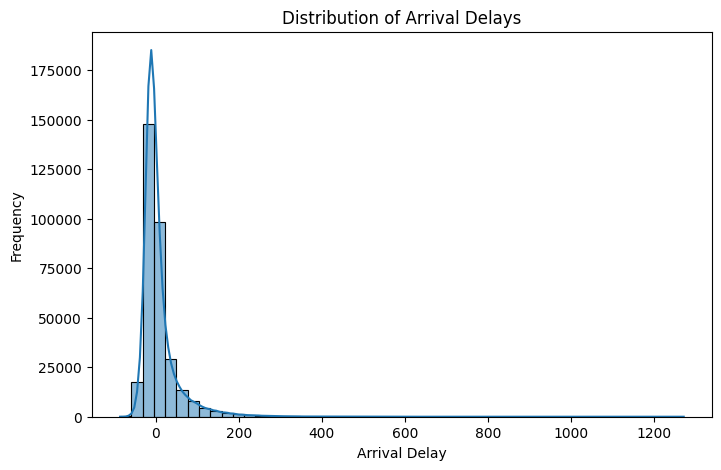

In [11]:
## DISTRIBUTION OF ARRIVAL DELAY :
plt.figure(figsize=(8,5))
sns.histplot(df['arr_delay'], bins=50, kde=True)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay")
plt.ylabel("Frequency")
plt.show()
##Most flights have small delays
##Some flights show large outliers

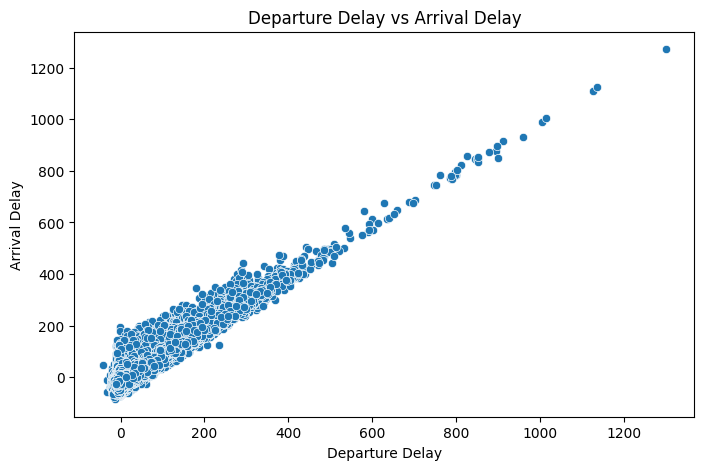

In [12]:
## DEPARTURE DELAY VS ARRIVAL DELAY
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['dep_delay'], y=df['arr_delay'])
plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.show()
##Flights departing late usually arrive late.

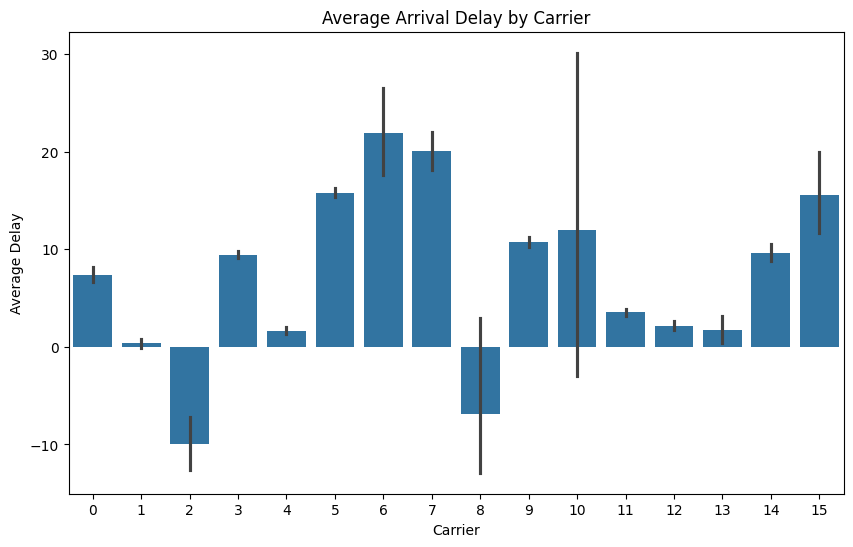

In [13]:
## CARRIER VS AVERAGE DELAY
plt.figure(figsize=(10,6))
sns.barplot(x='carrier', y='arr_delay', data=df)
plt.title("Average Arrival Delay by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Average Delay")
plt.show()

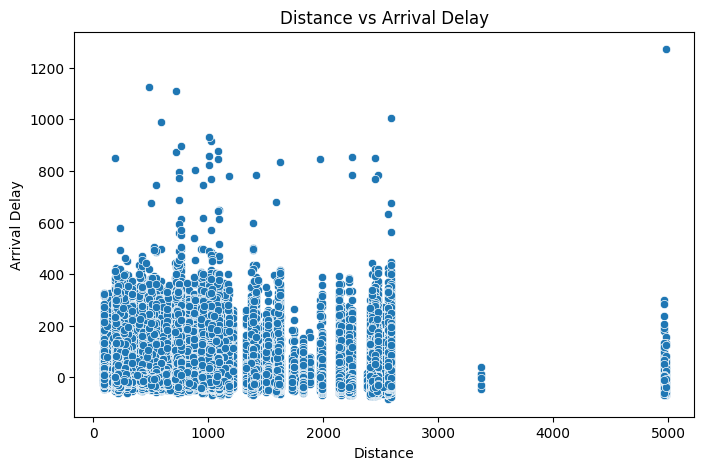

In [14]:
## DISTANCE VS ARRIVAL DELAY
plt.figure(figsize=(8,5))
sns.scatterplot(x='distance', y='arr_delay', data=df)
plt.title("Distance vs Arrival Delay")
plt.xlabel("Distance")
plt.ylabel("Arrival Delay")
plt.show()

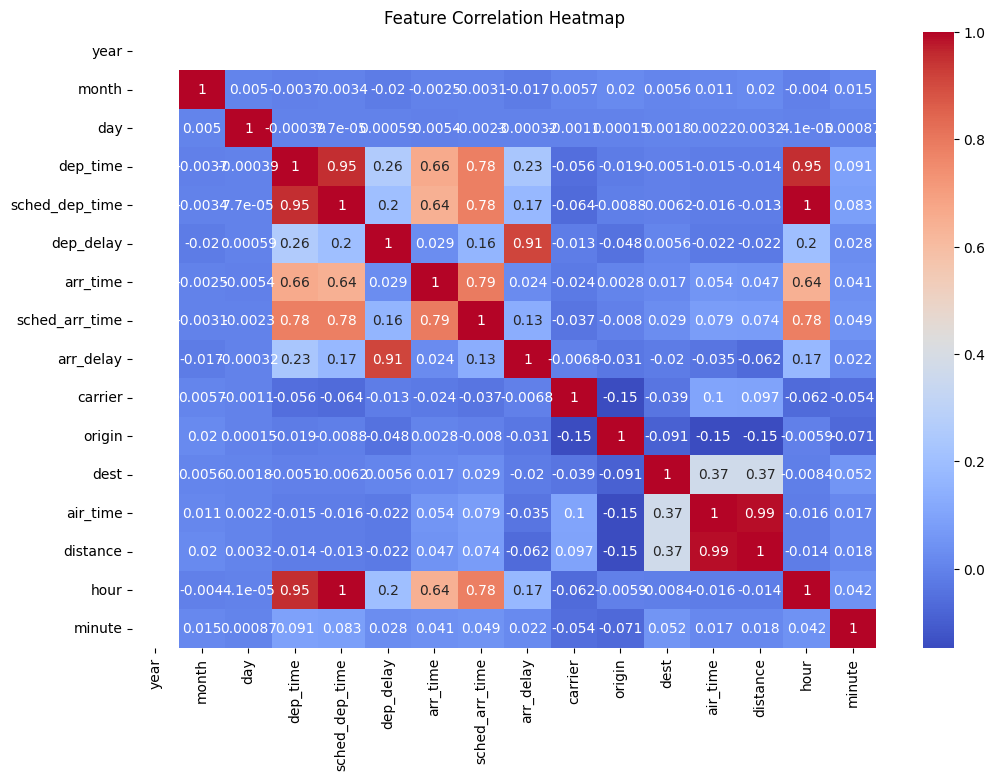

In [15]:
## CORELATION HEATMAP
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

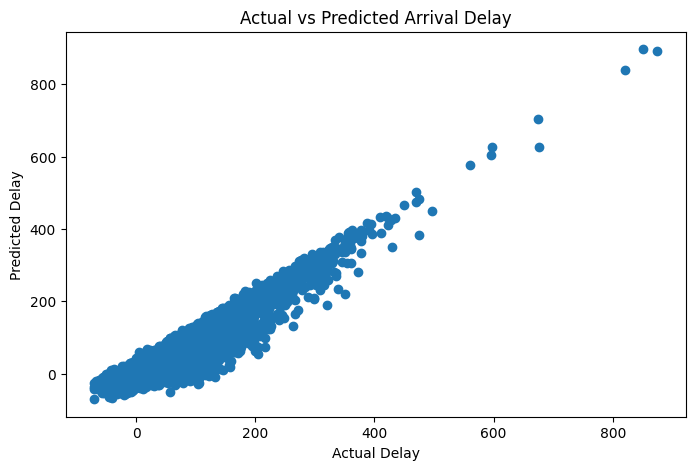

In [16]:
## ACTUAL VS PREDICTIVE DELAY
plt.figure(figsize=(8,5))
plt.scatter(y_test, pred_lr)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted Arrival Delay")
plt.show()

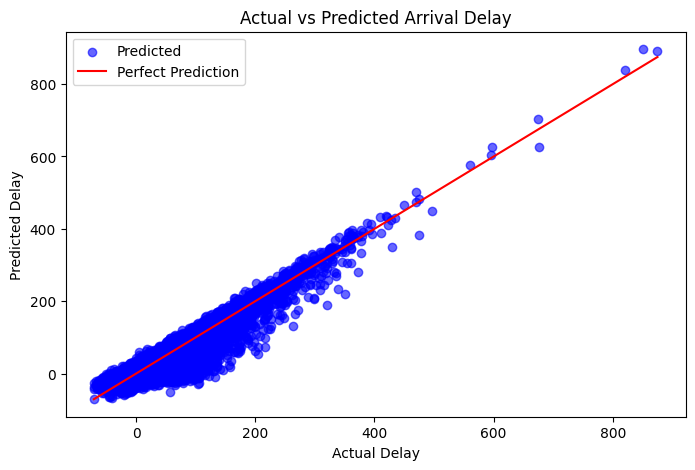

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

# scatter points
plt.scatter(y_test, pred_lr, color="blue", alpha=0.6, label="Predicted")

# diagonal reference line
line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(line, line, color="red", label="Perfect Prediction")

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted Arrival Delay")

plt.legend()
plt.show()